In [ ]:
try:
    import firedrake
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    import firedrake

--2026-07-17 07:18:22--  https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4868 (4.8K) [application/x-sh]
Saving to: ‘/tmp/firedrake-install.sh’

/tmp/firedrake-inst 100%[===================>]   4.75K  --.-KB/s    in 0s      

2026-07-17 07:18:22 (50.5 MB/s) - ‘/tmp/firedrake-install.sh’ saved [4868/4868]

+ INSTALL_PREFIX=/usr/local
++ echo /usr/local
++ awk -F/ '{print NF-1}'
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FIREDRAKE_INSTALLED=/usr/local/share/fem-on-colab/firedrake.installed
+ [[ ! -f /usr/local/share/fem-on-colab/firedrake.installed ]]
+ PYBIND11_INSTALL_SCRIPT_PATH=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/e12a

In [ ]:
from firedrake import *
from firedrake.mg.interface import prolong
import numpy as np
from scipy.sparse import lil_matrix,csr_matrix
from firedrake import *
import matplotlib.pyplot as plt
import numpy as np
from firedrake.petsc import PETSc
import petsc4py
from time import perf_counter

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


err (src-risource) = 0.6732601675054104 0.0492579727148465


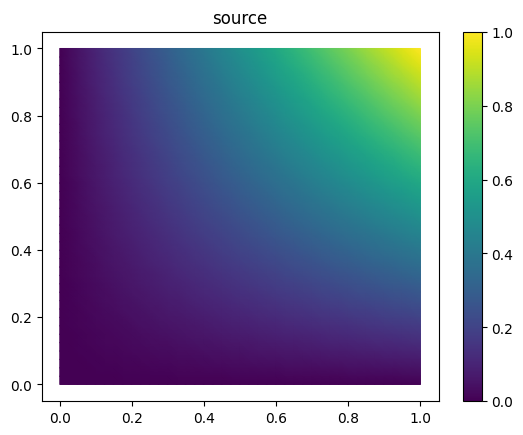

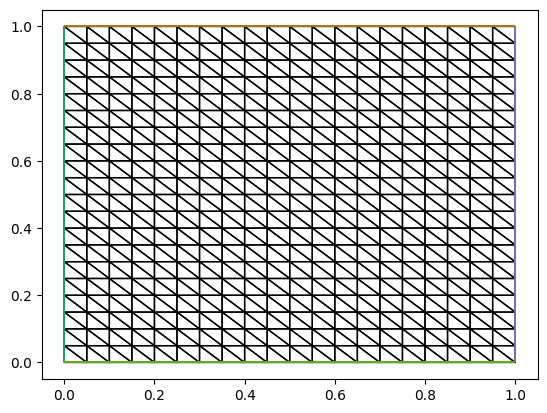

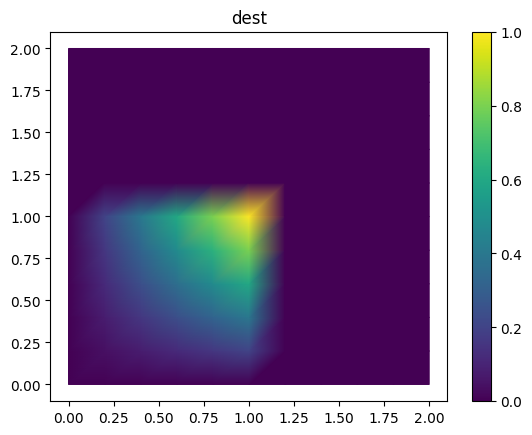

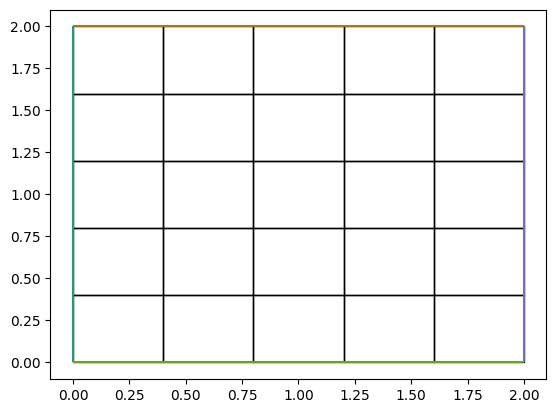

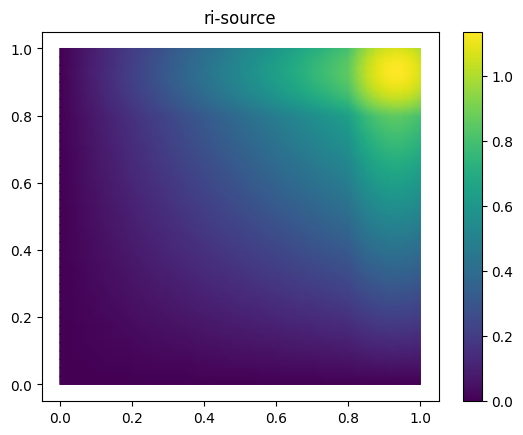

In [ ]:
# These meshes only share some of their domain
src_mesh = UnitSquareMesh(20, 20)
dest_mesh = UnitSquareMesh(5, 5, quadrilateral=True)
dest_mesh.coordinates.dat.data_wo[:] *= 2

# We consider a simple function on our source mesh...
x_src, y_src = SpatialCoordinate(src_mesh)
V_src = FunctionSpace(src_mesh, "CG", 2)
f_src = Function(V_src).interpolate(x_src*y_src)

aa=tripcolor(f_src)
plt.title('source')
plt.colorbar(aa)
triplot(src_mesh)


# ... and want to interpolate into a function space on our target mesh ...
V_dest = FunctionSpace(dest_mesh, "Q", 2)


# Setting the allow_missing_dofs keyword allows the interpolation to proceed.
# f_dest = assemble(interpolate(f_src, V_dest, allow_missing_dofs=True))

f_dest = Function(V_dest)
f_dest.interpolate(f_src, allow_missing_dofs=True)
aa=tripcolor(f_dest, edgecolor='1')
plt.title('dest')
plt.colorbar(aa)
triplot(dest_mesh)


f_risource = Function(V_src)
f_risource.interpolate(f_dest, allow_missing_dofs=True)
aa=tripcolor(f_risource, edgecolor='1')
plt.title('ri-source')
plt.colorbar(aa)

print("err (src-risource) =", errornorm(f_src,f_risource,'H1'), errornorm(f_src,f_risource,'L2'))

In [ ]:
def laplacian_forms(V, uex, ubd, delta):
  u, v = TrialFunction(V), TestFunction(V)
  a = inner(grad(u), grad(v))*dx + u*v*dx + delta*u*v*ds
  L = (uex-Constant(4))*v*dx + delta*ubd*v*ds
  return a, L

uh_src = Function(V_src)
uh_dest_to_src = Function(V_src)
uh_dest = Function(V_dest)
uh_src_to_dest = Function(V_dest)

uex_src = x_src*x_src + y_src*y_src
x_dest, y_dest = SpatialCoordinate(dest_mesh)
uex_dest = x_dest*x_dest + y_dest*y_dest

uh_dest.interpolate(uex_dest)
uh_dest_to_src.interpolate(uh_dest, allow_missing_dofs=True)
a, L = laplacian_forms(V_src, uex_src, uh_dest_to_src, Constant(1.0e+20))
solve(a == L, uh_src)
print(errornorm(uex_src, uh_src), errornorm(uex_dest, uh_dest))

# import obstacles
# uh_src.interpolate(uex_src)
# uh_src_to_dest.interpolate(uh_src, allow_missing_dofs=True)
# obstacle = obstacles.squareObstacle(3, 3, 1.0/10)
# print(obstacle.distStr())
# a, L = laplacian_forms(V_dest, uex_dest, uh_src_to_dest, obstacle.delta())
# solve(a == L, uh_dest)
# print(errornorm(uex_src, uh_src), errornorm(uex_dest, uh_dest))

4.58068401736236e-15 1.9738280261055226e-15


In [ ]:
def scipy_to_PETSc(A_scipy):
    # converts csr_matrix SciPy in PETSc Mat
    A_petsc = PETSc.Mat().createAIJ(size=A_scipy.shape,
                                    csr=(A_scipy.indptr, A_scipy.indices, A_scipy.data))

    return A_petsc